In [1]:
from google.colab import files
uploaded = files.upload()


Saving breastcancer.csv to breastcancer.csv


In [2]:
import pandas as pd

data = pd.read_csv("breastcancer.csv")
print(data.head())


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [4]:
# drop id column
if 'id' in data.columns:
    data = data.drop('id', axis=1)

# drop empty column if exists
if 'Unnamed: 32' in data.columns:
    data = data.drop('Unnamed: 32', axis=1)


In [5]:
# convert diagnosis (M/B → 0/1)
data['diagnosis'] = data['diagnosis'].map({'M': 0, 'B': 1})


In [6]:
print(data.isnull().sum())


diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


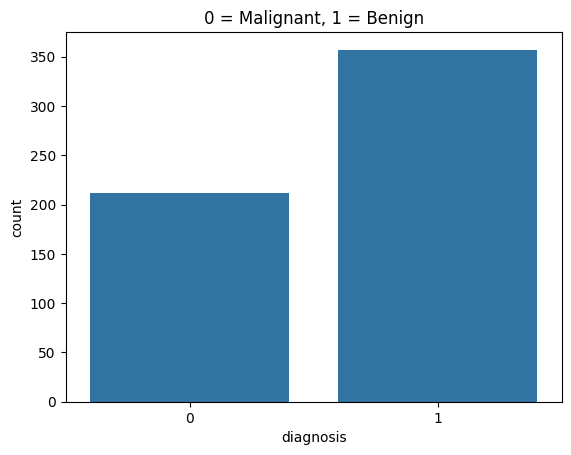

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='diagnosis', data=data)
plt.title("0 = Malignant, 1 = Benign")
plt.show()


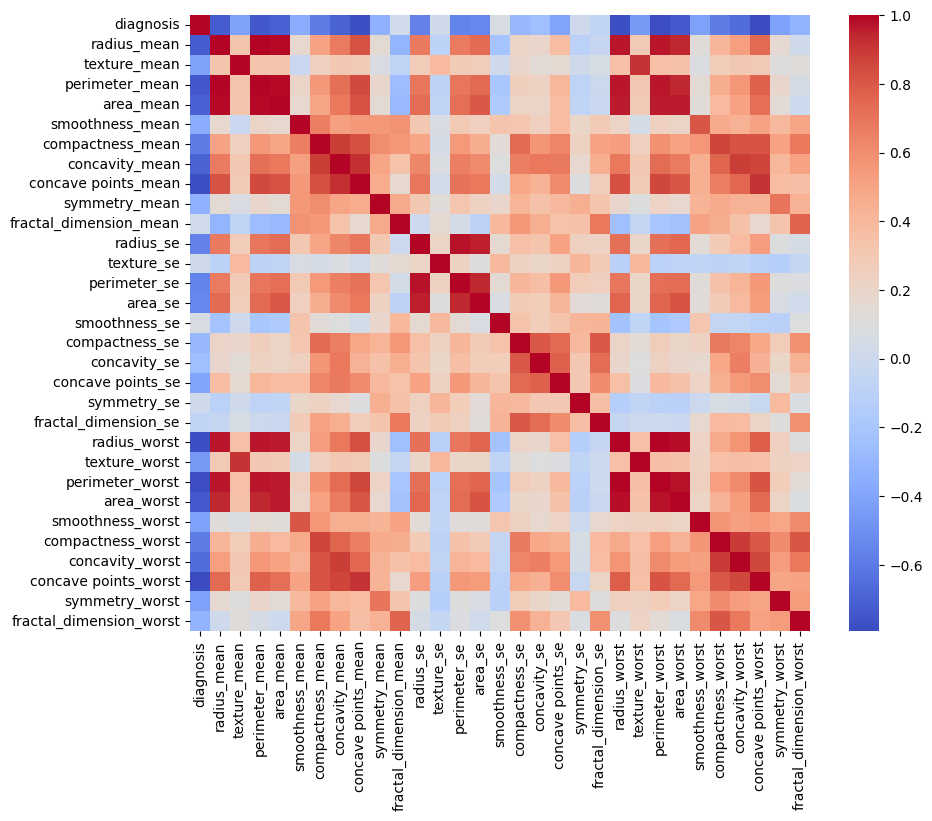

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.show()


In [9]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [14]:
model.fit(X_train, y_train, epochs=15, batch_size=32)


Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7451 - loss: 0.5675
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9407 - loss: 0.2760 
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9538 - loss: 0.1767
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1309
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9714 - loss: 0.1086  
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9758 - loss: 0.0938 
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9758 - loss: 0.0837 
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0753 
Epoch 9/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0688 
Epoch 10/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0639 
Epoch 11/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0589 
Epoch 12/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

In [15]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9825 - loss: 0.0683 
Accuracy: 0.9824561476707458


In [16]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9825 - loss: 0.0683
Accuracy: 0.9824561476707458


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


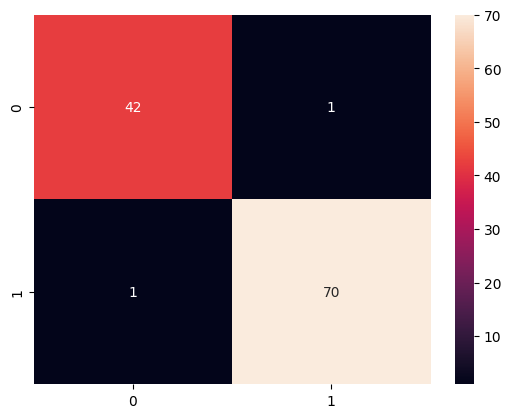

In [17]:
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test)
pred = (pred > 0.5).astype(int)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

